In [ ]:
# Installation code
%pip install seaborn matplotlib

# Cars Visualization Problem


Load two datasets: "Long Format" and "Wide Format" from the `cars.xlsx` file.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Load cars.xlsx dataset with the 'wide' sheet, skipping 2 rows and using the first row as header
df_raw = pd.read_excel('cars.xlsx', sheet_name='Long Format', skiprows=0, header=0) 

# lower-case column names for consistency and replace spaces with _
df_raw = df_raw.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))

# Fix percent field.
df_raw['percent'] = df_raw['percent'] / 100.0

df_long = df_raw.copy()  # Create a copy of the raw dataframe for manipulation

df_long

,model_year,percent,color
0,2025,0.000,Gold
1,2025,0.000,Purple
2,1997,0.001,Orange
3,1998,0.001,Orange
4,1999,0.001,Orange
...,...,...,...
385,2023,0.269,White
386,2019,0.272,White
387,2022,0.272,White
388,2021,0.281,White


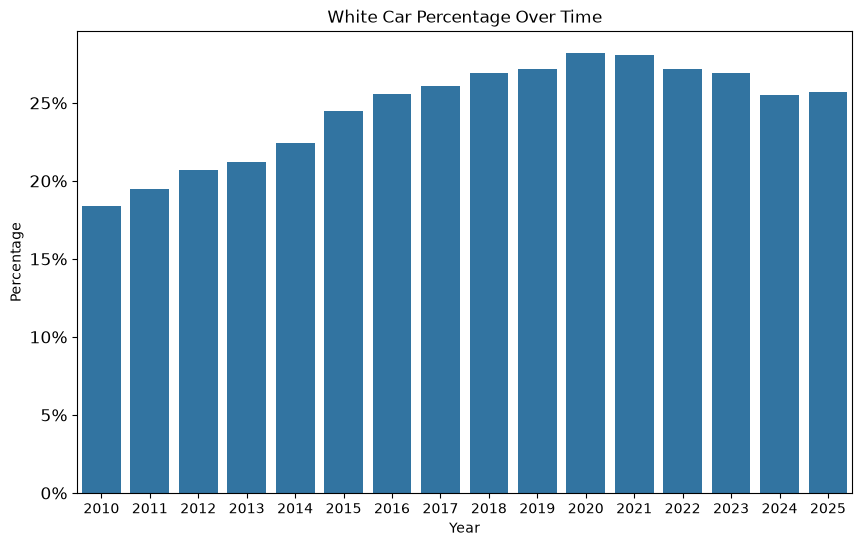

In [ ]:
# Show white cars since 2010 with a bar chart.

# Filter for White cars.
df_white = df_long[df_long['color'] == 'White']

# Show last 10 years only.
df_white = df_white[df_white['model_year'] >= 2010]

# Create a barchart showing the white color percentage over time.
plt.figure(figsize=(10, 6))
sns.barplot(data=df_white, x='model_year', y='percent')
plt.title('White Car Percentage Over Time')
plt.xlabel('Year')
plt.ylabel('Percentage')
# Show y as a percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# Increase font size for better readability
plt.yticks(fontsize=12)

plt.show()


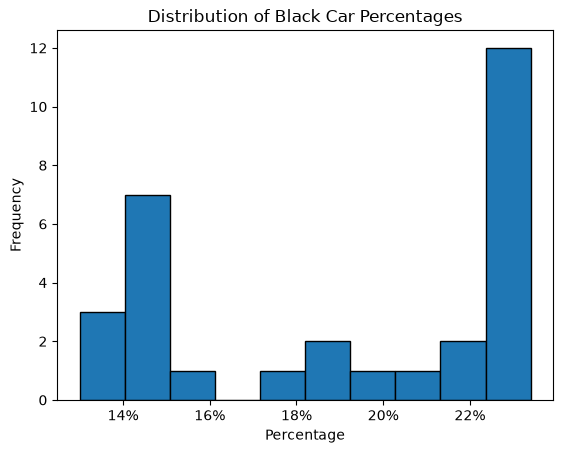

In [17]:
# Show a histogram of black car percentages 

df_black = df_long[df_long['color'] == 'Black']

plt.hist(df_black['percent'], bins=10, edgecolor='black')
plt.title('Distribution of Black Car Percentages')
plt.xlabel('Percentage')
plt.ylabel('Frequency')

# Format x-axis as percentage
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

plt.show()

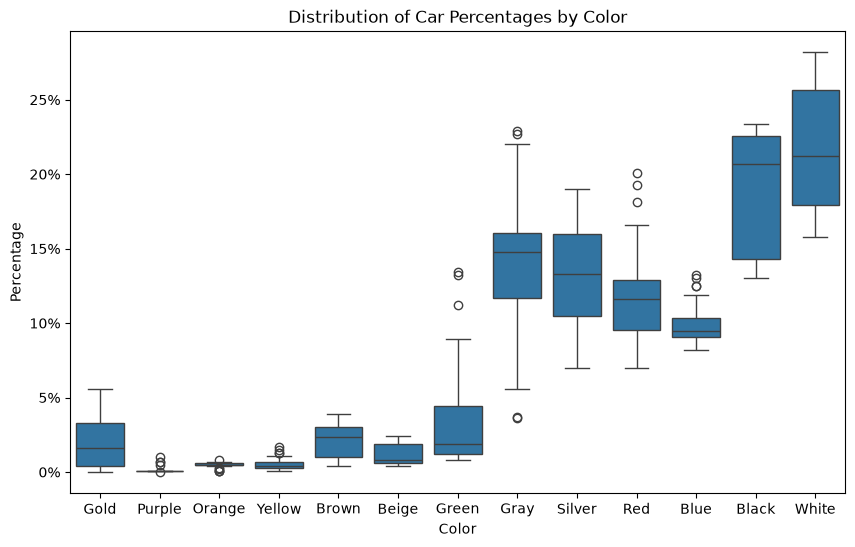

In [18]:
# Create a boxplot to compare the distribution of car percentages by color.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x='color', y='percent')
plt.title('Distribution of Car Percentages by Color')
plt.xlabel('Color')
plt.ylabel('Percentage')
# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
plt.show()

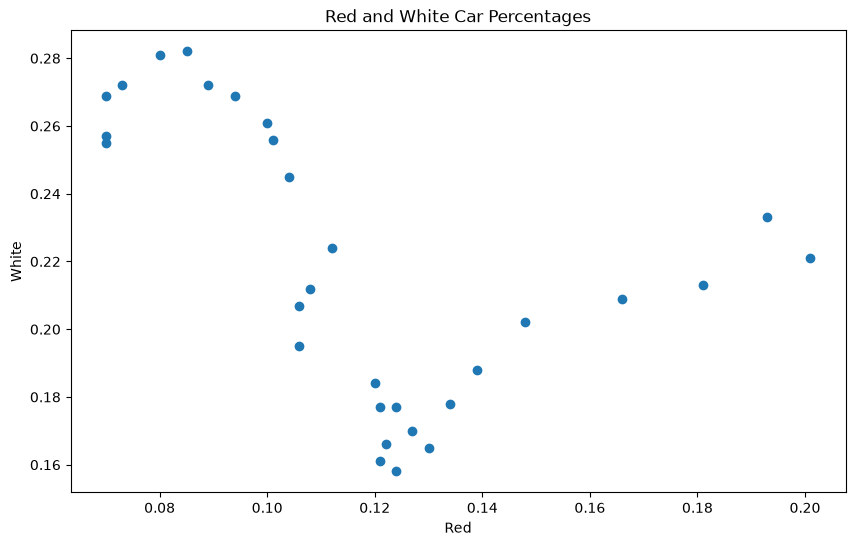

In [28]:
# Create a scatterplot showing the red and black color relationship over time.
df_wb = df_long[df_long['color'].isin(['Red', 'White'])]

# Pivot to a wide format to compare Red and White percentages side by side.
df_wb_pivot = df_wb.pivot(index='model_year', columns='color', values='percent').reset_index()

# Create a scatterplot, using model_year as the label for the points, and Red and White percentages as the x and y coordinates.
plt.figure(figsize=(10, 6))
plt.scatter(x = df_wb_pivot['Red'], y = df_wb_pivot['White'])
plt.title('Red and White Car Percentages')
plt.xlabel('Red')
plt.ylabel('White')
plt.show()

In [ ]:
# Create a pairplot of the top5 colors.

df_top5_colors = df_long.groupby(by = 'color').agg(
    n = ('color', 'count'),
    mean_percent = ('percent', 'mean')
)

# Sort by mean_percent and take the top 5 colors.
df_top5_colors = df_top5_colors.sort_values(by='mean_percent', ascending=False).head(5).reset_index()


#sns.pairplot(df_wide)
#plt.show()

,color,n,mean_percent
0,White,30,0.218633
1,Black,30,0.189900
2,Gray,30,0.138667
3,Silver,30,0.133167
4,Red,30,0.117300
